# 🏠 CNN People Counter — Regression from Images

Train a CNN to estimate **how many people live in a picture** (200×200 px).  
The target is extracted from the **last number in each filename** (e.g. `house_district5_3.jpg` → target = **3**).

---

In [1]:
# Install dependencies (uncomment if needed)
# !pip install torch torchvision matplotlib scikit-learn pillow tqdm

In [2]:
import os
import re
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm.auto import tqdm

print(f"PyTorch {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

PyTorch 2.11.0+cu128
Using device: cuda


## 1. Configuration

Adjust the settings below to match your setup.

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CONFIGURE THESE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA_DIR    = "../../Data"   # ← change this
IMG_SIZE    = 200
BATCH_SIZE  = 128
NUM_SAMPLES = -1
EPOCHS      = 5
LR          = 1e-3
VAL_SPLIT   = 0.2
DROPOUT     = 0.3
PATIENCE    = 10       # early stopping patience
OUTPUT_DIR  = "output"
SEED        = 42
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

## 2. Dataset

The target (number of people) is extracted from the **last number** in each filename before the extension.

| Filename | Target |
|---|---|
| `house_district5_3.jpg` | 3 |
| `img_001_12.png` | 12 |
| `photo-7.jpeg` | 7 |

In [4]:
def extract_target_from_filename(filename: str) -> int:
    """Return the last integer found in the filename (before extension)."""
    stem = Path(filename).stem
    numbers = re.findall(r"\d+", stem)
    if not numbers:
        raise ValueError(f"No numeric target found in filename: {filename}")
    return int(numbers[-1])


class PeopleCountDataset(Dataset):
    """Loads images from a directory; target = last number in filename."""

    VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

    def __init__(self, root_dir: str, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for f in sorted(self.root_dir.iterdir()):
            if f.suffix.lower() in self.VALID_EXT:
                try:
                    target = extract_target_from_filename(f.name)
                    self.samples.append((f, target))
                except ValueError:
                    print(f"  ⚠ Skipping {f.name} — no target in name")

        if not self.samples:
            raise FileNotFoundError(
                f"No valid images in {root_dir}. Check the path and filename format."
            )

        targets = [t for _, t in self.samples]
        print(f"✓ Loaded {len(self.samples)} images")
        print(f"  Target range: {min(targets)} – {max(targets)}  "
              f"(mean {np.mean(targets):.1f}, std {np.std(targets):.1f})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(target, dtype=torch.float32)

## 3. Data Transforms & Loaders

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.Resize((224, 224)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.Resize((224, 224)),
])

In [ ]:
# Load full dataset
full_dataset = PeopleCountDataset(DATA_DIR, transform=None)
full_dataset.samples = full_dataset.samples[:NUM_SAMPLES]

# ── Balance: equal number of 0-people vs has-people ──────────
zero_samples = [s for s in full_dataset.samples if s[1] == 0]
nonzero_samples = [s for s in full_dataset.samples if s[1] > 0]

# Downsample the larger group to match the smaller group
n_balanced = min(len(zero_samples), len(nonzero_samples))
random.shuffle(zero_samples)
random.shuffle(nonzero_samples)
full_dataset.samples = zero_samples[:n_balanced] + nonzero_samples[:n_balanced]
random.shuffle(full_dataset.samples)

print(f"Balanced: {n_balanced} zero-people + {n_balanced} with-people = {len(full_dataset.samples)} total")
# ──────────────────────────────────────────────────────────────

val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

train_subset, val_subset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_dataset = PeopleCountDataset(DATA_DIR, transform=train_transform)
train_dataset.samples = [full_dataset.samples[i] for i in train_subset.indices]

val_dataset = PeopleCountDataset.__new__(PeopleCountDataset)
val_dataset.root_dir = full_dataset.root_dir
val_dataset.transform = val_transform
val_dataset.samples = [full_dataset.samples[i] for i in val_subset.indices]

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True,
)

print(f"Train: {len(train_dataset)} samples  |  Val: {len(val_dataset)} samples")

✓ Loaded 88869 images
  Target range: 0 – 201  (mean 1.3, std 6.8)
Balanced: 9961 zero-people + 9961 with-people = 19922 total
✓ Loaded 88869 images
  Target range: 0 – 201  (mean 1.3, std 6.8)
Train: 15938 samples  |  Val: 3984 samples


## 4. Quick EDA — Target Distribution

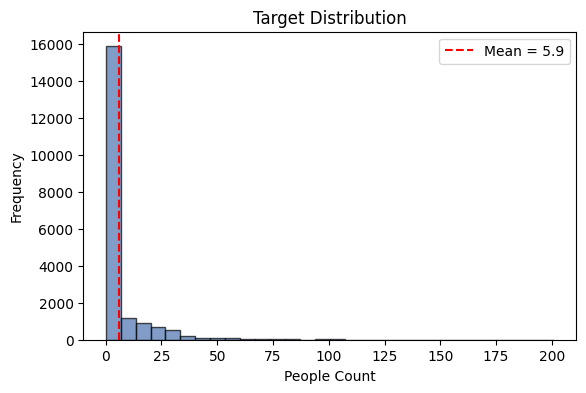

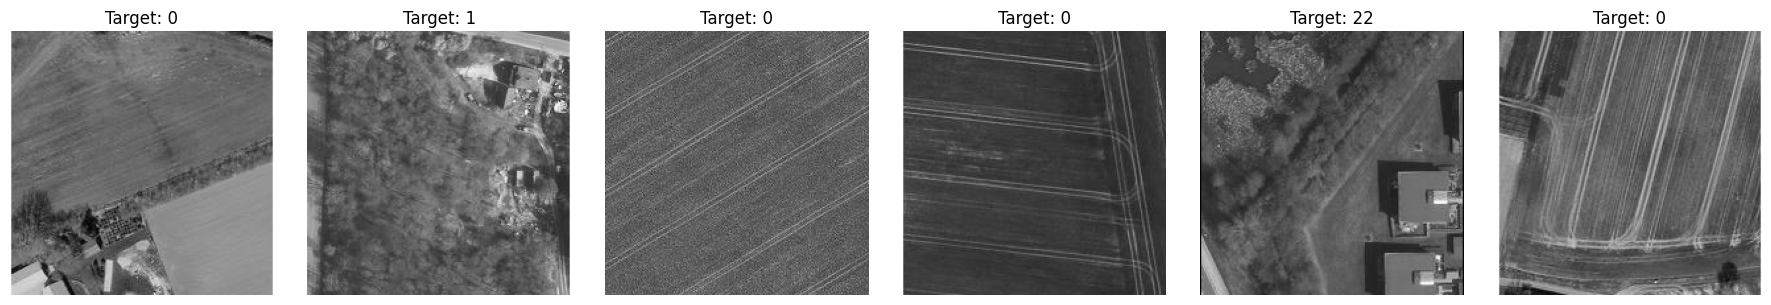

In [7]:
targets = [t for _, t in full_dataset.samples]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(targets, bins=30, edgecolor="black", alpha=0.7, color="#4C72B0")
axes[0].set_xlabel("People Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Target Distribution")
axes[0].axvline(np.mean(targets), color="red", linestyle="--", label=f"Mean = {np.mean(targets):.1f}")
axes[0].legend()

# Show a few sample images
sample_indices = random.sample(range(len(full_dataset)), min(6, len(full_dataset)))
axes[1].set_visible(False)

fig2, axes2 = plt.subplots(1, min(6, len(full_dataset)), figsize=(18, 3))
if not isinstance(axes2, np.ndarray):
    axes2 = [axes2]
for ax, idx in zip(axes2, sample_indices):
    path, target = full_dataset.samples[idx]
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(f"Target: {target}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Pretrained Transformer
 pretrained on ImageNet

In [8]:
import timm

class PeopleCountViT(nn.Module):
    def __init__(self, dropout=0.3, backbone='vit_small_patch16_224'):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)
        self.regressor = nn.Sequential(
            nn.LayerNorm(self.backbone.num_features),
            nn.Dropout(dropout),
            nn.Linear(self.backbone.num_features, 1),
        )

    def forward(self, x):
        return self.regressor(self.backbone(x)).squeeze(-1)


model = PeopleCountViT(dropout=DROPOUT).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")


Model parameters: 21,666,817


## 6. Training

In [9]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

In [10]:
# MPS workaround: some ops need float32 fallback
if device.type == "mps":
    import os
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in tqdm(loader, desc="  Training", leave=False):
        imgs = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    return epoch_loss, mae


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        preds = model(imgs)
        loss = criterion(preds, targets)

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds) if len(set(all_targets)) > 1 else 0.0
    return epoch_loss, mae, r2, np.array(all_preds), np.array(all_targets)

In [11]:
best_val_loss = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

pbar = tqdm(range(1, EPOCHS + 1), desc="Training")

for epoch in pbar:
    train_loss, train_mae = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_mae, val_r2, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    pbar.set_postfix({
        "t_loss": f"{train_loss:.4f}",
        "v_loss": f"{val_loss:.4f}",
        "v_mae": f"{val_mae:.2f}",
        "v_r2": f"{val_r2:.3f}",
    })

    # Early stopping + checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_mae": val_mae,
        }, os.path.join(OUTPUT_DIR, "best_model.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\n✓ Training complete — best val loss: {best_val_loss:.4f}")

Training:   0%|          | 0/5 [00:00<?, ?it/s]

  Training:   0%|          | 0/499 [00:00<?, ?it/s]

  Training:   0%|          | 0/499 [00:00<?, ?it/s]

  Training:   0%|          | 0/499 [00:00<?, ?it/s]

  Training:   0%|          | 0/499 [00:00<?, ?it/s]

  Training:   0%|          | 0/499 [00:00<?, ?it/s]


✓ Training complete — best val loss: 135.5567


## 7. Training Curves

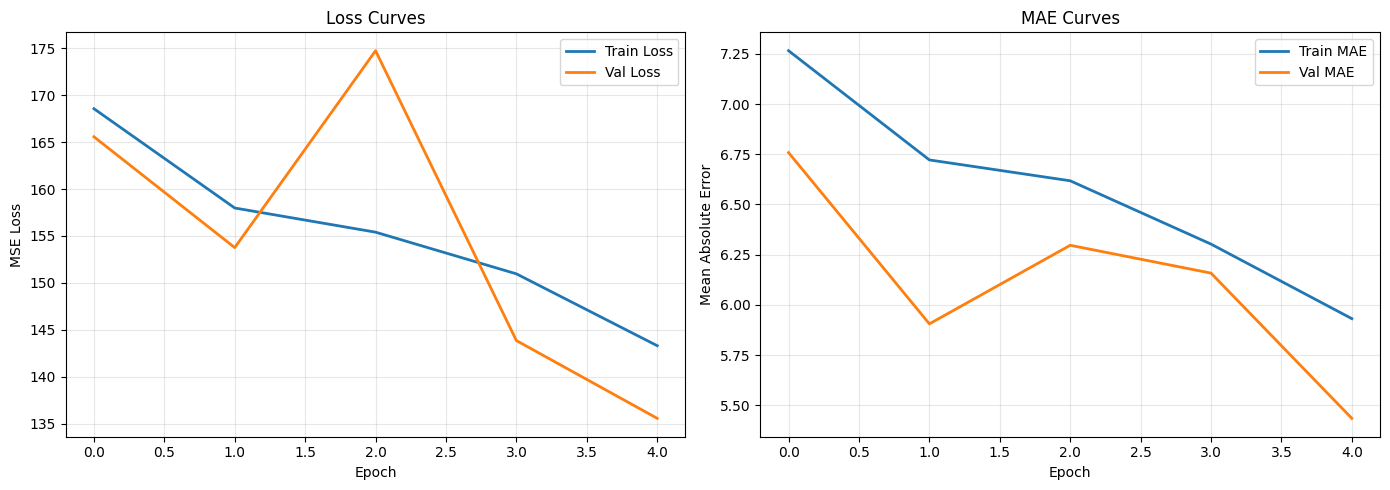

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_mae"], label="Train MAE", linewidth=2)
axes[1].plot(history["val_mae"], label="Val MAE", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Absolute Error")
axes[1].set_title("MAE Curves")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 8. Final Evaluation (Best Model)

In [13]:
# Load best checkpoint
ckpt = torch.load(os.path.join(OUTPUT_DIR, "best_model.pth"),
                   map_location=device, weights_only=True)
model.load_state_dict(ckpt["model_state_dict"])

val_loss, val_mae, val_r2, preds, targets = evaluate(model, val_loader, criterion)

print(f"Best model from epoch {ckpt['epoch']}:")
print(f"  Val MSE : {val_loss:.4f}")
print(f"  Val MAE : {val_mae:.2f}")
print(f"  Val R²  : {val_r2:.3f}")

Best model from epoch 5:
  Val MSE : 135.5567
  Val MAE : 5.44
  Val R²  : 0.273


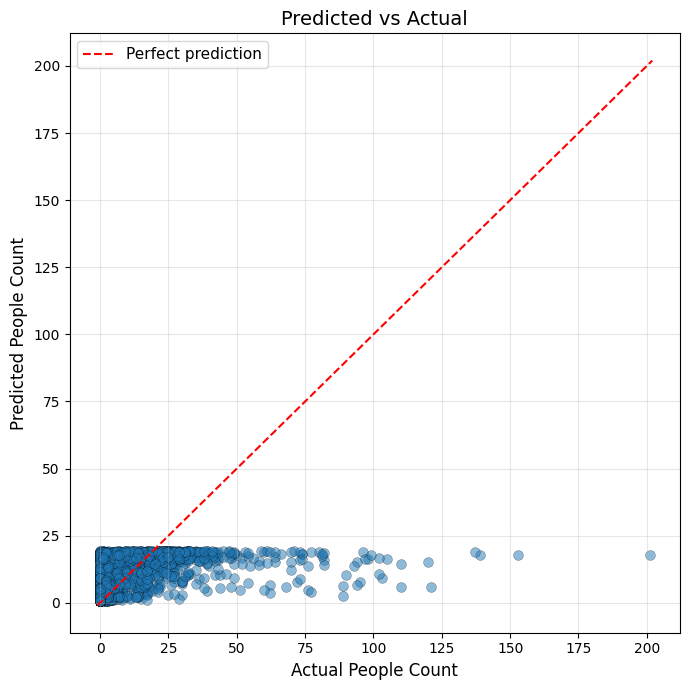

In [14]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(targets, preds, alpha=0.5, edgecolors="k", linewidth=0.3, s=50)
lims = [min(targets.min(), preds.min()) - 1,
        max(targets.max(), preds.max()) + 1]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual People Count", fontsize=12)
ax.set_ylabel("Predicted People Count", fontsize=12)
ax.set_title("Predicted vs Actual", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pred_vs_actual.png"), dpi=150)
plt.show()

## 9. Error Analysis

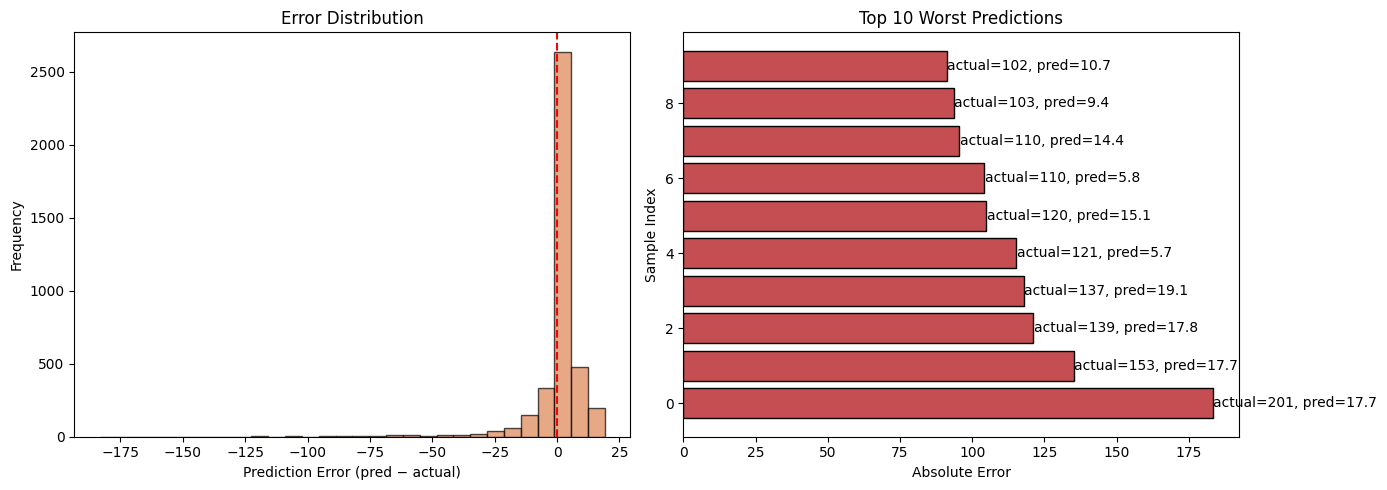

Median absolute error: 1.96
90th percentile error: 12.82
Within ±1 person:  27.0%
Within ±2 people:  50.4%


In [15]:
errors = preds - targets
abs_errors = np.abs(errors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=30, edgecolor="black", alpha=0.7, color="#DD8452")
axes[0].set_xlabel("Prediction Error (pred − actual)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Error Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Worst predictions
worst_idx = np.argsort(abs_errors)[-10:][::-1]
axes[1].barh(range(len(worst_idx)),
             abs_errors[worst_idx], color="#C44E52", edgecolor="black")
axes[1].set_xlabel("Absolute Error")
axes[1].set_ylabel("Sample Index")
axes[1].set_title("Top 10 Worst Predictions")
for i, idx in enumerate(worst_idx):
    axes[1].text(abs_errors[idx] + 0.1, i,
                 f"actual={targets[idx]:.0f}, pred={preds[idx]:.1f}", va="center")

plt.tight_layout()
plt.show()

print(f"Median absolute error: {np.median(abs_errors):.2f}")
print(f"90th percentile error: {np.percentile(abs_errors, 90):.2f}")
print(f"Within ±1 person:  {(abs_errors <= 1).mean()*100:.1f}%")
print(f"Within ±2 people:  {(abs_errors <= 2).mean()*100:.1f}%")

## 10. Inference on New Images

Use this cell to predict people count for any new image.

In [16]:
@torch.no_grad()
def predict_image(image_path: str, model, transform, device):
    """Predict people count for a single image."""
    model.eval()
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)
    prediction = model(tensor).item()
    return prediction, img


# Example usage (uncomment and set path):
# pred, img = predict_image("path/to/new_image.jpg", model, val_transform, device)
# plt.imshow(img.resize((IMG_SIZE, IMG_SIZE)))
# plt.title(f"Predicted: {pred:.1f} people")
# plt.axis("off")
# plt.show()